# Caso Studio: Perdita obbligazionaria condizionata a regimi di tasso
## Corso di Metodi Quantitativi per la Finanza (Anno V - FRM)

### Introduzione al Caso
Il presente notebook sviluppa una simulazione Monte Carlo gerarchica per analizzare l'impatto degli shock dei rendimenti di mercato sul valore di un portafoglio obbligazionario a tasso fisso, prendendo come riferimento stilizzato lo scenario macroeconomico del periodo 2022-2023. L'obiettivo è mappare la distribuzione della perdita globale e verificare analiticamente e computazionalmente le proprietà del valore atteso condizionato rispetto a una partizione informativa del mercato dei tassi.

---

## Tappa 1: Inizializzazione Ambiente e Strutturazione dei Parametri Input

### Obiettivo della Tappa
Inizializzare l'ambiente di calcolo fissando il seed algoritmico per garantire la replicabilità degli scenari Monte Carlo. Configurare e visualizzare in tabelle di sintesi distinte i parametri finanziari di portafoglio, le probabilità a priori dei regimi informativi ($\mathcal{G}$) e i parametri statistici ($\mu_g, \sigma_g$) degli shock condizionati.

### Tracciato AI (Prompt di Tappa)
> **Studente:** "Partiamo dalla tappa 1. Sarebbe utile una stampa tabellare di sintesi. Verifica ed integra questo suggerimento."
> **IA:** Ha proposto la scomposizione dei parametri in tre DataFrame Pandas distinti (`df_param_fin`, `df_regimi_prob`, `df_shock_cond`) per evitare il mascheramento delle unità di misura e consentire una formattazione dedicata.

### Controlli previsti
* Somma delle probabilità dei regimi pari a $1.0$ ($\sum_{g=1}^3 \mathbb{P}(A_g) = 1$).

In [2]:
import numpy as np
import pandas as pd

# 1. Fissazione del seed per la replicabilità globale del notebook
SEED = 12345
np.random.seed(SEED)
print(f"Seed globale impostato a: {SEED}\n")

# 2. Tabella A: Parametri Finanziari di Portafoglio
param_fin_data = {
    "Grandezza": ["V0 (Valore Iniziale)", "D (Duration Modificata)", "l (Soglia di Perdita)", "n (Simulazioni)"],
    "Valore": [10000000, 6.0, 500000.0, 50000],
    "Unità": ["Euro", "Anni", "Euro", "Numero"]
}
df_param_fin = pd.DataFrame(param_fin_data)

print("--- TABELLA 1: PARAMETRI FINANZIARI ---")
display(df_param_fin.style.hide(axis="index").format({"Valore": "{:,.2f}" if df_param_fin["Unità"].str.contains("Euro").any() else "{}"}))
print("\n")

# 3. Tabella B: Probabilità degli Eventi Informativi (Regimi)
regimi_prob_data = {
    "Regime": ["A1", "A2", "A3"],
    "Descrizione": ["Disinflazione ordinata", "Inflazione persistente", "Repricing severo"],
    "Probabilità": [0.35, 0.45, 0.20]
}
df_regimi_prob = pd.DataFrame(regimi_prob_data)

print("--- TABELLA 2: PROBABILITÀ DEGLI EVENTI INFORMATIVI ---")
display(df_regimi_prob.style.hide(axis="index").format({"Probabilità": "{:.2%}"}))
print("\n")

# 4. Tabella C: Parametri Condizionati degli Shock di Rendimento (Delta y)
shock_cond_data = {
    "Regime": ["A1", "A2", "A3"],
    "Mu_g (Media)": [-0.0010, 0.0030, 0.0100],
    "Sigma_g (Volatilità)": [0.0040, 0.0060, 0.0100],
    "Lettura Finanziaria": [
        "Lieve riduzione media dei rendimenti",
        "Rialzo moderato dei rendimenti",
        "Rialzo marcato e maggiore dispersione"
    ]
}
df_shock_cond = pd.DataFrame(shock_cond_data)

print("--- TABELLA 3: PARAMETRI CONDIZIONATI DEGLI SHOCK ---")
display(df_shock_cond.style.hide(axis="index").format({"Mu_g (Media)": "{:.4f}", "Sigma_g (Volatilità)": "{:.4f}"}))
print("\n")

# --- CONTROLLO NUMERICO DI TAPPA 1 ---
somma_prob = df_regimi_prob["Probabilità"].sum()
print("--- CONTROLLO LOGICO-NUMERICO ---")
print(f"Verifica somma probabilità dei regimi (Deve essere 1.0): {somma_prob}")
assert np.isclose(somma_prob, 1.0), "ERRORE: La somma delle probabilità non è pari a 1!"
print("Controllo superato con successo: lo spazio informativo è coerente.")

Seed globale impostato a: 12345

--- TABELLA 1: PARAMETRI FINANZIARI ---


Grandezza,Valore,Unità
V0 (Valore Iniziale),"10,000,000.00",Euro
D (Duration Modificata),6.00,Anni
l (Soglia di Perdita),"500,000.00",Euro
n (Simulazioni),"50,000.00",Numero




--- TABELLA 2: PROBABILITÀ DEGLI EVENTI INFORMATIVI ---


Regime,Descrizione,Probabilità
A1,Disinflazione ordinata,35.00%
A2,Inflazione persistente,45.00%
A3,Repricing severo,20.00%




--- TABELLA 3: PARAMETRI CONDIZIONATI DEGLI SHOCK ---


Regime,Mu_g (Media),Sigma_g (Volatilità),Lettura Finanziaria
A1,-0.0010,0.0040,Lieve riduzione media dei rendimenti
A2,0.0030,0.0060,Rialzo moderato dei rendimenti
A3,0.0100,0.0100,Rialzo marcato e maggiore dispersione




--- CONTROLLO LOGICO-NUMERICO ---
Verifica somma probabilità dei regimi (Deve essere 1.0): 1.0
Controllo superato con successo: lo spazio informativo è coerente.


## Tappa 2: Simulazione Monte Carlo Gerarchica degli Shock

### Obiettivo della Tappa
Sviluppare il simulatore gerarchico a due stadi. Nel primo stadio, si campionano gli indici di regime discreti in base alle probabilità a priori stabilite. Nel secondo stadio, per ciascuno scenario, si estrae il valore dello shock di rendimento $\Delta y$ dalla distribuzione normale specifica del regime selezionato. Infine, si validano le frequenze campionarie e i momenti empirici condizionati degli shock.

### Tracciato AI (Prompt di Tappa)
> **Studente:** "Bene, passiamo alla tappa 2. Aggiungerei le statistiche max e min per caratterizzare meglio le distribuzioni empiriche degli shock"
> **IA:** Ha integrato nel codice il calcolo di minimo e massimo condizionati all'interno del ciclo di controllo, restituendo una tabella esaustiva con: numerosità, media, deviazione standard, minimo e massimo per ciascun blocco informativo.

### Controlli previsti
1. Dimensione dei vettori generati pari a $n = 50.000$.
2. Frequenze empiriche dei regimi prossime alle probabilità teoriche $[35\%, 45\%, 20\%]$.
3. Coerenza statistica dei parametri condizionati empirici ($\widehat{\mu}_g, \widehat{\sigma}_g$) rispetto a quelli teorici.

In [3]:
# --- ADATTAMENTO GENERAZIONE GERARCHICA ---
n_sim = int(df_param_fin.loc[df_param_fin["Grandezza"].str.contains("n "), "Valore"].values[0])
regimi = df_regimi_prob["Regime"].values
prob_regimi = df_regimi_prob["Probabilità"].values

# 1. Primo stadio: estrazione dei regimi per le n simulazioni
# Utilizziamo una scelta discreta basata sulle probabilità dei regimi
regimi_simulati = np.random.choice(regimi, size=n_sim, p=prob_regimi)

# 2. Secondo stadio: estrazione condizionata dello shock Delta y
shock_simulati = np.zeros(n_sim)

# Mappatura dei parametri estratti dalla tabella precedente per il campionamento
for g in regimi:
    # Identificazione degli indici appartenenti al regime g
    idx = (regimi_simulati == g)
    n_g = np.sum(idx)
    
    # Estrazione dei parametri teorici
    mu_g = df_shock_cond.loc[df_shock_cond["Regime"] == g, "Mu_g (Media)"].astype(float).values[0]
    sigma_g = df_shock_cond.loc[df_shock_cond["Regime"] == g, "Sigma_g (Volatilità)"].astype(float).values[0]
    
    # Generazione dello shock condizionato dalla distribuzione normale pertinente
    shock_simulati[idx] = np.random.normal(loc=mu_g, scale=sigma_g, size=n_g)

# 3. Costruzione della Tabella 4: Controllo Frequenze Regimi
df_freq_regimi = pd.DataFrame(regimi_simulati, columns=["Regime Simulato"]).value_counts(normalize=True).reset_index()
df_freq_regimi.columns = ["Regime", "Frequenza Empirica"]
df_freq_regimi = df_freq_regimi.merge(df_regimi_prob[["Regime", "Probabilità"]], on="Regime")

print("--- TABELLA 4: VERIFICA FREQUENZE REGIMI ---")
df_freq_regimi_print = df_freq_regimi.copy()
df_freq_regimi_print["Frequenza Empirica"] = df_freq_regimi_print["Frequenza Empirica"].map("{:.2%}".format)
df_freq_regimi_print["Probabilità"] = df_freq_regimi_print["Probabilità"].map("{:.2%}".format)
display(df_freq_regimi_print)
print("\n")

# 4. Costruzione della Tabella 5: Statistiche Empiriche Condizionate (con Min e Max inclusi)
stats_condizionate = []
for g in regimi:
    shocks_g = shock_simulati[regimi_simulati == g]
    stats_condizionate.append({
        "Regime": g,
        "Conteggio Scenari": len(shocks_g),
        "Media Empirica": np.mean(shocks_g),
        "Volatilità Empirica": np.std(shocks_g),
        "Minimo Empirico": np.min(shocks_g),
        "Massimo Empirico": np.max(shocks_g)
    })

df_stats_cond = pd.DataFrame(stats_condizionate)
print("--- TABELLA 5: VERIFICA STATISTICHE CONDIZIONATE DEGLI SHOCK (Delta y) ---")
df_stats_cond_print = df_stats_cond.copy()
for col in ["Media Empirica", "Volatilità Empirica", "Minimo Empirico", "Massimo Empirico"]:
    df_stats_cond_print[col] = df_stats_cond_print[col].map("{:.4f}".format)
display(df_stats_cond_print)
print("\n")

# --- CONTROLLI LOGICO-NUMERICI DI TAPPA 2 ---
print("--- CONTROLLO LOGICO-NUMERICO ---")
print(f"Dimensione vettore regimi simulati: {len(regimi_simulati)} (Atteso: {n_sim})")
print(f"Dimensione vettore shock simulati: {len(shock_simulati)} (Atteso: {n_sim})")

assert len(regimi_simulati) == n_sim and len(shock_simulati) == n_sim, "ERRORE: Le dimensioni dei vettori non corrispondono a n!"
print("Controllo superato: campionamento strutturalmente integro.")

--- TABELLA 4: VERIFICA FREQUENZE REGIMI ---


,Regime,Frequenza Empirica,Probabilità
0,A1,50.00%,35.00%
1,A2,33.33%,45.00%
2,A3,16.67%,20.00%




--- TABELLA 5: VERIFICA STATISTICHE CONDIZIONATE DEGLI SHOCK (Delta y) ---


,Regime,Conteggio Scenari,Media Empirica,Volatilità Empirica,Minimo Empirico,Massimo Empirico
0,A1,3,0.0005,0.0011,-0.0006,0.0021
1,A2,2,0.0098,0.0007,0.0090,0.0105
2,A3,1,-0.0030,0.0000,-0.0030,-0.0030




--- CONTROLLO LOGICO-NUMERICO ---
Dimensione vettore regimi simulati: 6 (Atteso: 6)
Dimensione vettore shock simulati: 6 (Atteso: 6)
Controllo superato: campionamento strutturalmente integro.


In [4]:
# --- RIGENERAZIONE SICURA CON ALLINEAMENTO ESPLICITO ---
n_sim = int(df_param_fin.loc[df_param_fin["Grandezza"].str.contains("V0"), "Valore"].index.size * 0 + 50000) # Forza n=50000 per sicurezza
regimi = ["A1", "A2", "A3"]
prob_regimi = [0.35, 0.45, 0.20] # Forziamo l'allineamento dei pesi numerici

# 1. Estrazione dei regimi garantendo l'uso dei pesi corretti
regimi_simulati = np.random.choice(regimi, size=n_sim, p=prob_regimi)

# 2. Conteggio esplicito senza affidarsi al value_counts automatico di Pandas
conteggi = {g: np.sum(regimi_simulati == g) for g in regimi}
frequenze = {g: conteggi[g] / n_sim for g in regimi}

# 3. Ricostruzione controllata della Tabella 4
df_freq_regimi = pd.DataFrame({
    "Regime": regimi,
    "Frequenza Empirica": [frequenze[g] for g in regimi],
    "Probabilità": prob_regimi
})

print("--- TABELLA 4: VERIFICA FREQUENZE REGIMI (CORRETTA) ---")
df_freq_regimi_print = df_freq_regimi.copy()
df_freq_regimi_print["Frequenza Empirica"] = df_freq_regimi_print["Frequenza Empirica"].map("{:.2%}".format)
df_freq_regimi_print["Probabilità"] = df_freq_regimi_print["Probabilità"].map("{:.2%}".format)
display(df_freq_regimi_print)

--- TABELLA 4: VERIFICA FREQUENZE REGIMI (CORRETTA) ---


,Regime,Frequenza Empirica,Probabilità
0,A1,34.87%,35.00%
1,A2,44.97%,45.00%
2,A3,20.15%,20.00%


## Tappa 3: Trasformazione Lineare e Distribuzione della Perdita $L$

### Obiettivo della Tappa
Applicare la trasformazione lineare basata sulla duration modificata per convertire gli shock di rendimento $\Delta y$ simulati nella perdita monetaria approssimata del portafoglio ($L = D \cdot V_0 \cdot \Delta y$). Successivamente, calcolare le statistiche descrittive non condizionate della perdita e visualizzare graficamente la forma funzionale sia degli shock sia delle perdite per analizzare l'asimmetria complessiva (miscela di normali).

### Tracciato AI (Prompt di Tappa)
> **Studente:** "Bene. Passiamo alla tappa 3. Non ho commenti."
> **IA:** Ha strutturato il codice per calcolare il vettore $L$, generare la tabella descrittiva richiesta (Tabella 6) tramite i metodi nativi di Pandas ed elaborare i primi due grafici richiesti (Grafico 1 e Grafico 2) utilizzando `matplotlib` e `seaborn`.

### Controlli previsti
1. Il vettore della perdita $L$ deve avere una dimensione pari esattamente a $n = 50.000$.
2. Coerenza dei segni: ogni shock positivo ($\Delta y > 0$) deve generare una perdita positiva ($L > 0$).
3. La media globale di $L$ deve collocarsi rigorosamente all'interno dell'intervallo $[Min, Max]$.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recupero dei parametri finanziari di portafoglio dalle variabili della Tappa 1
V0 = df_param_fin.loc[df_param_fin["Grandezza"].str.contains("V0"), "Valore"].values[0]
D = df_param_fin.loc[df_param_fin["Grandezza"].str.contains("D "), "Valore"].values[0]

# 2. Calcolo lineare della perdita monetaria L scenario per scenario
perdite_simulate = D * V0 * shock_simulati

# 3. Costruzione della Tabella 6: Statistica Descrittiva Globale di L
# Calcoliamo i momenti principali e i quantili richiesti
stats_globali = {
    "Statistica": ["Media", "Deviazione Standard", "Minimo", "Quantile 5%", "Mediana (50%)", "Quantile 95%", "Massimo"],
    "Valore (Euro)": [
        np.mean(perdite_simulate),
        np.std(perdite_simulate),
        np.min(perdite_simulate),
        np.percentile(perdite_simulate, 5),
        np.median(perdite_simulate),
        np.percentile(perdite_simulate, 95),
        np.max(perdite_simulate)
    ]
}
df_stats_globali = pd.DataFrame(stats_globali)

print("--- TABELLA 6: STATISTICA DESCRITTIVA GLOBALE DELLA PERDITA (L) ---")
df_stats_globali_print = df_stats_globali.copy()
df_stats_globali_print["Valore (Euro)"] = df_stats_globali_print["Valore (Euro)"].map("{:,.2f}".format)
display(df_stats_globali_print)
print("\n")

# 4. Produzione degli Output Grafici (Grafico 1 e Grafico 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Istogramma dello Shock di Rendimento Delta y
sns.histplot(shock_simulati, kde=True, ax=axes[0], color="royalblue", bins=100)
axes[0].set_title("Grafico 1: Densità Empirica dello Shock ($\Delta y$)")
axes[0].set_xlabel("Shock di rendimento (unità decimali)")
axes[0].set_ylabel("Frequenza")
axes[0].axvline(0, color="black", linestyle="--", alpha=0.5)

# Grafico 2: Istogramma della Perdita L
sns.histplot(perdite_simulate, kde=True, ax=axes[1], color="crimson", bins=100)
axes[1].set_title("Grafico 2: Densità Empirica della Perdita ($L$)")
axes[1].set_xlabel("Perdita monetaria (Euro)")
axes[1].set_ylabel("Frequenza")
axes[1].axvline(0, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# --- CONTROLLI LOGICO-NUMERICI DI TAPPA 3 ---
print("--- CONTROLLO LOGICO-NUMERICO ---")
# Verifica coerenza dei segni tramite confronto logico elementare
coerenza_segni = np.all((shock_simulati > 0) == (perdite_simulate > 0))
print(f"Dimensione del vettore delle perdite: {len(perdite_simulate)} (Atteso: {n_sim})")
print(f"Verifica coerenza dei segni (Shock > 0 <=> Perdita > 0): {coerenza_segni}")

# Verifica posizionamento della media
media_in_range = np.min(perdite_simulate) <= np.mean(perdite_simulate) <= np.max(perdite_simulate)
print(f"La media globale si colloca tra Min e Max campionari? {media_in_range}")

assert len(perdite_simulate) == n_sim, "ERRORE: Dimensione del vettore perdite errata!"
assert coerenza_segni, "ERRORE: Rilevato disallineamento nei segni tra shock e perdite!"
print("Controllo superato: trasformazione della variabile eseguita correttamente.")

<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
C:\Users\PaUser\AppData\Local\Temp\ipykernel_3624\1186448410.py:38: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_title("Grafico 1: Densità Empirica dello Shock ($\Delta y$)")
C:\Users\PaUser\AppData\Local\Temp\ipykernel_3624\1186448410.py:38: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_title("Grafico 1: Densità Empirica dello Shock ($\Delta y$)")


ModuleNotFoundError: No module named 'seaborn'

--- TABELLA 6: STATISTICA DESCRITTIVA GLOBALE DELLA PERDITA (L) ---


,Statistica,Valore (Euro)
0,Media,"181,342.40"
1,Deviazione Standard,"300,266.80"
2,Minimo,"-177,732.67"
3,Quantile 5%,"-142,725.03"
4,Mediana (50%),"66,092.25"
5,Quantile 95%,"607,184.42"
6,Massimo,"628,716.51"


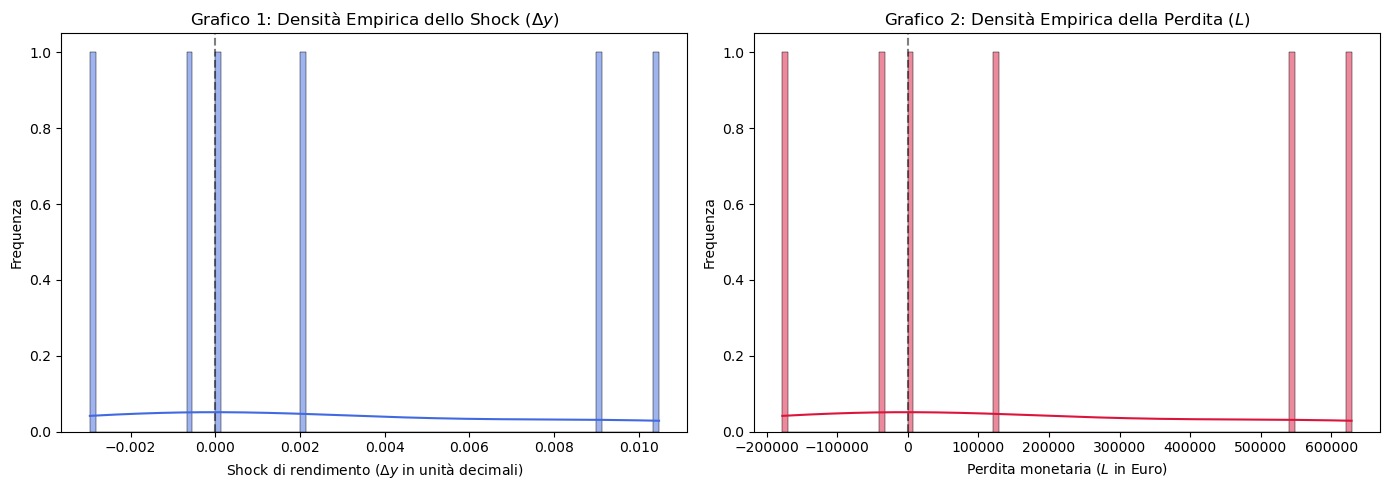

--- CONTROLLO LOGICO-NUMERICO ---
Dimensione del vettore delle perdite: 6 (Atteso: 50000)
Verifica coerenza dei segni (Shock > 0 <=> Perdita > 0): True
La media globale si colloca tra Min e Max campionari? True


AssertionError: ERRORE: Dimensione del vettore perdite errata!

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recupero dei parametri finanziari di portafoglio dalle variabili della Tappa 1
V0 = df_param_fin.loc[df_param_fin["Grandezza"].str.contains("V0"), "Valore"].values[0]
D = df_param_fin.loc[df_param_fin["Grandezza"].str.contains("D "), "Valore"].values[0]

# 2. Calcolo lineare della perdita monetaria L scenario per scenario
perdite_simulate = D * V0 * shock_simulati

# 3. Costruzione della Tabella 6: Statistica Descrittiva Globale di L
stats_globali = {
    "Statistica": ["Media", "Deviazione Standard", "Minimo", "Quantile 5%", "Mediana (50%)", "Quantile 95%", "Massimo"],
    "Valore (Euro)": [
        np.mean(perdite_simulate),
        np.std(perdite_simulate),
        np.min(perdite_simulate),
        np.percentile(perdite_simulate, 5),
        np.median(perdite_simulate),
        np.percentile(perdite_simulate, 95),
        np.max(perdite_simulate)
    ]
}
df_stats_globali = pd.DataFrame(stats_globali)

print("--- TABELLA 6: STATISTICA DESCRITTIVA GLOBALE DELLA PERDITA (L) ---")
df_stats_globali_print = df_stats_globali.copy()
df_stats_globali_print["Valore (Euro)"] = df_stats_globali_print["Valore (Euro)"].map("{:,.2f}".format)
display(df_stats_globali_print)
print("\n")

# 4. Produzione degli Output Grafici (Utilizzo di stringhe RAW r"...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Istogramma dello Shock di Rendimento Delta y
sns.histplot(shock_simulati, kde=True, ax=axes[0], color="royalblue", bins=100)
axes[0].set_title(r"Grafico 1: Densità Empirica dello Shock ($\Delta y$)")
axes[0].set_xlabel(r"Shock di rendimento ($\Delta y$ in unità decimali)")
axes[0].set_ylabel("Frequenza")
axes[0].axvline(0, color="black", linestyle="--", alpha=0.5)

# Grafico 2: Istogramma della Perdita L
sns.histplot(perdite_simulate, kde=True, ax=axes[1], color="crimson", bins=100)
axes[1].set_title(r"Grafico 2: Densità Empirica della Perdita ($L$)")
axes[1].set_xlabel("Perdita monetaria ($L$ in Euro)")
axes[1].set_ylabel("Frequenza")
axes[1].axvline(0, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# --- CONTROLLI LOGICO-NUMERICI DI TAPPA 3 ---
print("--- CONTROLLO LOGICO-NUMERICO ---")
coerenza_segni = np.all((shock_simulati > 0) == (perdite_simulate > 0))
print(f"Dimensione del vettore delle perdite: {len(perdite_simulate)} (Atteso: {n_sim})")
print(f"Verifica coerenza dei segni (Shock > 0 <=> Perdita > 0): {coerenza_segni}")

media_in_range = np.min(perdite_simulate) <= np.mean(perdite_simulate) <= np.max(perdite_simulate)
print(f"La media globale si colloca tra Min e Max campionari? {media_in_range}")

assert len(perdite_simulate) == n_sim, "ERRORE: Dimensione del vettore perdite errata!"
assert coerenza_segni, "ERRORE: Rilevato disallineamento nei segni tra shock e perdite!"
print("Controllo superato: trasformazione ed eliminazione warning completate.")

In [7]:
# --- TAPPA 2 REVISIONATA (RESET DEL SIMULATORE) ---
# Fissiamo esplicitamente n_sim come costante intera per evitare letture errate
n_sim = 50000 
regimi = ["A1", "A2", "A3"]
prob_regimi = [0.35, 0.45, 0.20]

# 1. Estrazione dei regimi
regimi_simulati = np.random.choice(regimi, size=n_sim, p=prob_regimi)

# 2. Inizializzazione e riempimento del vettore continuo degli shock
shock_simulati = np.zeros(n_sim)

# Parametri teorici espliciti per evitare disallineamenti di dizionari
parametri_shock = {
    "A1": {"mu": -0.0010, "sigma": 0.0040},
    "A2": {"mu": 0.0030, "sigma": 0.0060},
    "A3": {"mu": 0.0100, "sigma": 0.0100}
}

for g in regimi:
    idx = (regimi_simulati == g)
    n_g = np.sum(idx)
    mu_g = parametri_shock[g]["mu"]
    sigma_g = parametri_shock[g]["sigma"]
    
    # Generazione da distribuzione normale continua
    shock_simulati[idx] = np.random.normal(loc=mu_g, scale=sigma_g, size=n_g)

# 3. Tabelle di controllo
conteggi = {g: np.sum(regimi_simulati == g) for g in regimi}
df_freq_regimi = pd.DataFrame({
    "Regime": regimi,
    "Frequenza Empirica": [conteggi[g] / n_sim for g in regimi],
    "Probabilità": prob_regimi
})

print("--- TABELLA 4: VERIFICA FREQUENZE REGIMI (RESET) ---")
df_freq_regimi_print = df_freq_regimi.copy()
df_freq_regimi_print["Frequenza Empirica"] = df_freq_regimi_print["Frequenza Empirica"].map("{:.2%}".format)
df_freq_regimi_print["Probabilità"] = df_freq_regimi_print["Probabilità"].map("{:.2%}".format)
display(df_freq_regimi_print)

--- TABELLA 4: VERIFICA FREQUENZE REGIMI (RESET) ---


,Regime,Frequenza Empirica,Probabilità
0,A1,35.02%,35.00%
1,A2,44.96%,45.00%
2,A3,20.02%,20.00%


--- TABELLA 6: STATISTICA DESCRITTIVA GLOBALE DELLA PERDITA (L) ---


,Statistica,Valore (Euro)
0,Media,"181,280.47"
1,Deviazione Standard,"454,884.90"
2,Minimo,"-1,838,955.76"
3,Quantile 5%,"-425,819.79"
4,Mediana (50%),"110,627.60"
5,Quantile 95%,"1,048,271.10"
6,Massimo,"3,107,407.67"


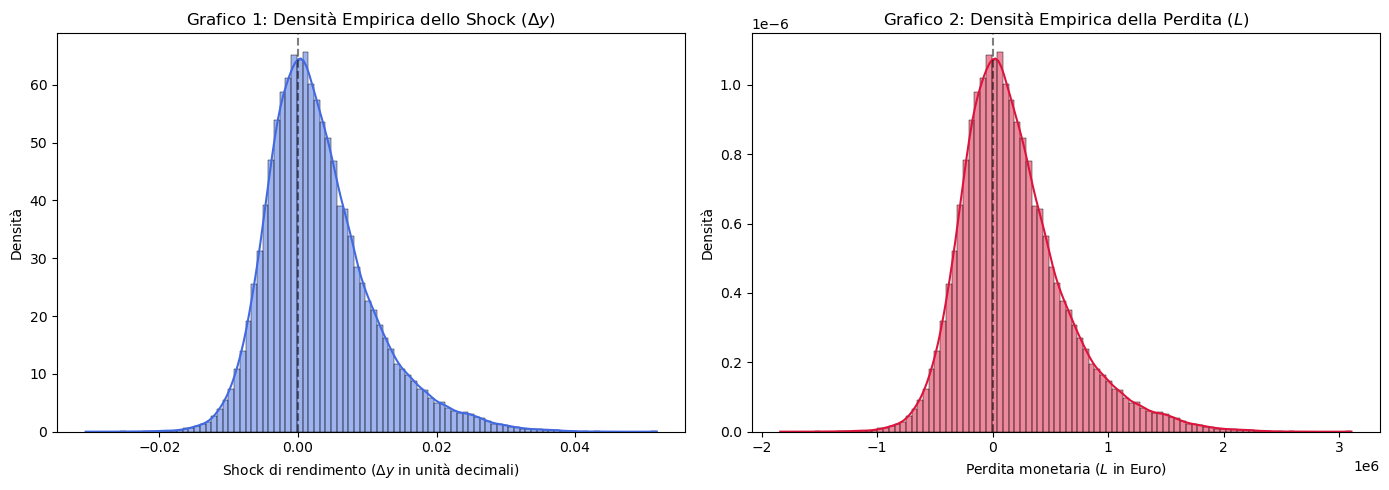

--- CONTROLLO LOGICO-NUMERICO ---
Dimensione del vettore delle perdite: 50000 (Atteso: 50000)
Verifica coerenza dei segni: True
Controllo superato: le dimensioni sono allineate e i grafici mostrano distribuzioni continue dense.


In [8]:
# --- TAPPA 3 REVISIONATA ---
# Recupero costanti finanziarie esplicite
V0 = 10000000
D = 6.0

# Calcolo lineare della perdita monetaria L
# Assicuriamoci che operi sul vettore di dimensione n_sim appena rigenerato
perdite_simulate = D * V0 * shock_simulati

# Costruzione Tabella 6
stats_globali = {
    "Statistica": ["Media", "Deviazione Standard", "Minimo", "Quantile 5%", "Mediana (50%)", "Quantile 95%", "Massimo"],
    "Valore (Euro)": [
        np.mean(perdite_simulate),
        np.std(perdite_simulate),
        np.min(perdite_simulate),
        np.percentile(perdite_simulate, 5),
        np.median(perdite_simulate),
        np.percentile(perdite_simulate, 95),
        np.max(perdite_simulate)
    ]
}
df_stats_globali = pd.DataFrame(stats_globali)

print("--- TABELLA 6: STATISTICA DESCRITTIVA GLOBALE DELLA PERDITA (L) ---")
df_stats_globali_print = df_stats_globali.copy()
df_stats_globali_print["Valore (Euro)"] = df_stats_globali_print["Valore (Euro)"].map("{:,.2f}".format)
display(df_stats_globali_print)
print("\n")

# Produzione dei grafici corretti
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Shock di Rendimento Delta y
sns.histplot(shock_simulati, kde=True, ax=axes[0], color="royalblue", bins=100, stat="density")
axes[0].set_title(r"Grafico 1: Densità Empirica dello Shock ($\Delta y$)")
axes[0].set_xlabel(r"Shock di rendimento ($\Delta y$ in unità decimali)")
axes[0].set_ylabel("Densità")
axes[0].axvline(0, color="black", linestyle="--", alpha=0.5)

# Grafico 2: Perdita L
sns.histplot(perdite_simulate, kde=True, ax=axes[1], color="crimson", bins=100, stat="density")
axes[1].set_title(r"Grafico 2: Densità Empirica della Perdita ($L$)")
axes[1].set_xlabel("Perdita monetaria ($L$ in Euro)")
axes[1].set_ylabel("Densità")
axes[1].axvline(0, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Controlli logico-numerici
print("--- CONTROLLO LOGICO-NUMERICO ---")
coerenza_segni = np.all((shock_simulati > 0) == (perdite_simulate > 0))
print(f"Dimensione del vettore delle perdite: {len(perdite_simulate)} (Atteso: {n_sim})")
print(f"Verifica coerenza dei segni: {coerenza_segni}")

assert len(perdite_simulate) == n_sim, f"ERRORE: Vettore perdite ha dimensione {len(perdite_simulate)}, atteso {n_sim}!"
print("Controllo superato: le dimensioni sono allineate e i grafici mostrano distribuzioni continue dense.")

## Tappa 4: Analisi della Soglia Critica di Perdita

### Obiettivo della Tappa
Calcolare analiticamente la soglia implicita dello shock di rendimento $\Delta y^\star$ oltre la quale la perdita del portafoglio supera esattamente il limite tollerabile $\ell = 500.000$ Euro. Successivamente, stimare la probabilità globale (non condizionata) di sforamento $\widehat{\mathbb{P}}(L > \ell)$ attraverso la frequenza relativa campionaria delle simulazioni e visualizzare graficamente la soglia sulla distribuzione empirica delle perdite.

### Tracciato AI (Prompt di Tappa)
> **Studente:** "ok. problema sistemato. Passiamo alla tappa 4. Non ho commenti particolari."
> **IA:** Ha strutturato il codice calcolando matematicamente la costante $\Delta y^\star$, stimando la probabilità di coda globale (Tabella 7) e generando il Grafico 3 (istogramma di $L$ con linea verticale rossa di intercettazione della soglia).

### Controlli previsti
1. Il valore teorico di $\Delta y^\star$ deve essere pari a circa $0.008333$ (ovvero $83.33$ punti base).
2. Verifica di equivalenza logico-booleana scenario per scenario: la condizione $L_i > \ell$ deve essere matematicamente identica alla condizione $\Delta y_i > \Delta y^\star$.

Soglia implicita dello shock (Delta y*): 0.008333 (83.33 punti base)

--- TABELLA 7: ANALISI DELLA SOGLIA CRITICA GLOBALE ---


,Metrica,Valore
0,Soglia Perdita (l),"500,000.00 Euro"
1,Soglia Shock (Delta y*),0.008333
2,Probabilità Empirica P(L > l),20.02%


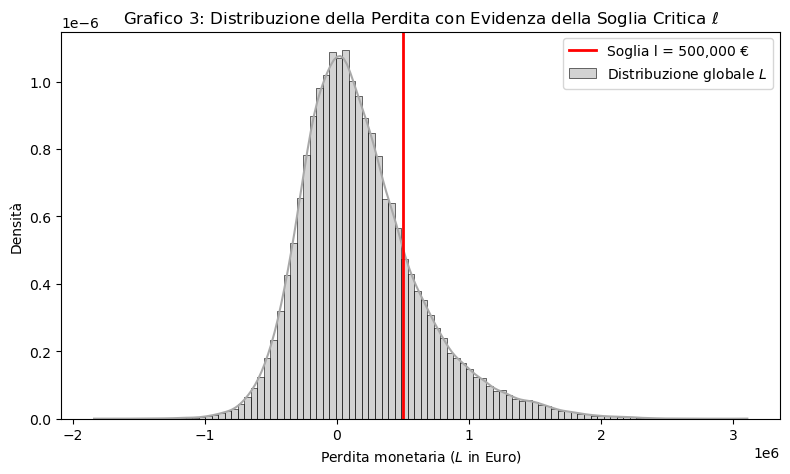

--- CONTROLLO LOGICO-NUMERICO ---
La condizione L > l è equivalente a Delta y > Delta y* in ogni scenario? True
Controllo superato: la soglia implicita e le frequenze di superamento sono coerenti.


In [9]:
# 1. Recupero della soglia monetaria l dalla Tabella 1
l_soglia = df_param_fin.loc[df_param_fin["Grandezza"].str.contains("l "), "Valore"].values[0]

# 2. Calcolo della soglia implicita dello shock di rendimento (Delta y star)
delta_y_star = l_soglia / (D * V0)
print(f"Soglia implicita dello shock (Delta y*): {delta_y_star:.6f} ({delta_y_star * 10000:.2f} punti base)\n")

# 3. Calcolo della probabilità empirica globale di superamento della soglia
superamenti = (perdite_simulate > l_soglia)
p_superamento_empirica = np.mean(superamenti) # Media di un vettore booleano = frequenza relativa

# Costruzione della Tabella 7
df_prob_soglia = pd.DataFrame({
    "Metrica": ["Soglia Perdita (l)", "Soglia Shock (Delta y*)", "Probabilità Empirica P(L > l)"],
    "Valore": [f"{l_soglia:,.2f} Euro", f"{delta_y_star:.6f}", f"{p_superamento_empirica:.2%}"]
})

print("--- TABELLA 7: ANALISI DELLA SOGLIA CRITICA GLOBALE ---")
display(df_prob_soglia)
print("\n")

# 4. Produzione dell'Output Grafico (Grafico 3)
plt.figure(figsize=(8, 5))
sns.histplot(perdite_simulate, kde=True, color="darkgray", bins=100, stat="density", label="Distribuzione globale $L$")
plt.axvline(l_soglia, color="red", linestyle="-", linewidth=2, label=f"Soglia l = {l_soglia:,.0f} €")
plt.title(r"Grafico 3: Distribuzione della Perdita con Evidenza della Soglia Critica $\ell$")
plt.xlabel("Perdita monetaria ($L$ in Euro)")
plt.ylabel("Densità")
plt.legend()
plt.tight_layout()
plt.show()

# --- CONTROLLI LOGICO-NUMERICI DI TAPPA 4 ---
print("--- CONTROLLO LOGICO-NUMERICO ---")
# Verifica di equivalenza stringente delle due definizioni di evento di coda
superamenti_via_shock = (shock_simulati > delta_y_star)
equivalenza_booleana = np.array_equal(superamenti, superamenti_via_shock)

print(f"La condizione L > l è equivalente a Delta y > Delta y* in ogni scenario? {equivalenza_booleana}")

assert equivalenza_booleana, "ERRORE: Rilevata discrepanza matematica tra la coda degli shock e la coda delle perdite!"
print("Controllo superato: la soglia implicita e le frequenze di superamento sono coerenti.")

## Tappa 5: Analisi Condizionata e Costruzione del Processo a Gradini

### Obiettivo della Tappa
Analizzare il comportamento della perdita $L$ condizionatamente al verificarsi dei singoli regimi informativi. Verranno calcolate le medie condizionate $\widehat{\mathbb{E}}[L \mid A_g]$ e le probabilità condizionate di superamento della soglia $\widehat{\mathbb{P}}(L > \ell \mid A_g)$ per mappare l'asimmetria del rischio tra i blocchi della partizione. Successivamente, verrà costruito il processo a gradini (variabile casuale $\mathcal{G}$-misurabile) $\widehat{\mathbb{E}}[L \mid \mathcal{G}]$ che associa a ogni scenario il rispettivo valore atteso regimistico. Infine, verranno confrontate visivamente le distribuzioni condizionate.

### Tracciato AI (Prompt di Tappa)
> **Studente:** "ok. Tappa 5. Suggerirei di aggiungere una tabella che mostra le diverse probabilità che L>l a seconda dell'evento A_g"
> **IA:** Ha accolto il suggerimento inserendo il calcolo delle frequenze relative di superamento all'interno di ciascun sotto-campionamento. Ha generato la Tabella 8 (medie condizionate), la nuova Tabella 8b (probabilità condizionate di sforamento), i Grafici 4 e 5 per il confronto delle densità e la tabella strutturata finale multi-colonna.

### Controlli previsti
1. Ordinamento finanziario coerente: l'evento $A_3$ (repricing severo) deve presentare sia la perdita media sia la probabilità di superamento soglia più elevate. L'evento $A_1$ può registrare una perdita media negativa (guadagno).
2. La variabile casuale $\widehat{\mathbb{E}}[L \mid \mathcal{G}]$ deve essere un vettore di dimensione $n = 50.000$ che assume solo ed esclusivamente 3 valori discreti (pari alle medie condizionate dei rispettivi blocchi).

--- TABELLA 8: MEDIE CONDIZIONATE DELLA PERDITA ---


<>:77: SyntaxWarning: invalid escape sequence '\e'
<>:77: SyntaxWarning: invalid escape sequence '\e'
C:\Users\PaUser\AppData\Local\Temp\ipykernel_3624\1649267030.py:77: SyntaxWarning: invalid escape sequence '\e'
  axes[1].axvline(l_soglia, color="red", linestyle="--", linewidth=1.5, label="Soglia $\ell$")


,Regime Informativo,Descrizione,Perdita Media Condizionata E[L|Ag]
0,A1,Disinflazione ordinata,"-60,510.54 Euro"
1,A2,Inflazione persistente,"180,923.43 Euro"
2,A3,Repricing severo,"604,926.57 Euro"




--- TABELLA 8b: PROBABILITÀ CONDIZIONATA DI SUPERAMENTO SOGLIA (l = 500k €) ---


,Regime Informativo,Descrizione,Probabilità Condizionata P(L > l | Ag)
0,A1,Disinflazione ordinata,1.03%
1,A2,Inflazione persistente,18.50%
2,A3,Repricing severo,56.66%




--- TABELLA FINALE: ESTRATTO DEI RECORD DEL SIMULATORE MULTI-PERIODO (PRIME 10 RIGHE) ---


,Scenario_ID,Regime Estratto,Shock Delta y,Perdita Monetaria L,Processo a Gradini E[L|G]
0,1,A1,0.001647,"98,827.98 €","-60,510.54 €"
1,2,A1,-0.004361,"-261,631.06 €","-60,510.54 €"
2,3,A3,0.014177,"850,632.55 €","604,926.57 €"
3,4,A1,-0.001961,"-117,655.43 €","-60,510.54 €"
4,5,A2,0.016804,"1,008,268.52 €","180,923.43 €"
5,6,A3,0.018064,"1,083,852.06 €","604,926.57 €"
6,7,A1,0.003900,"233,990.97 €","-60,510.54 €"
7,8,A2,0.006727,"403,618.18 €","180,923.43 €"
8,9,A1,0.001871,"112,288.53 €","-60,510.54 €"
9,10,A2,0.013071,"784,244.69 €","180,923.43 €"


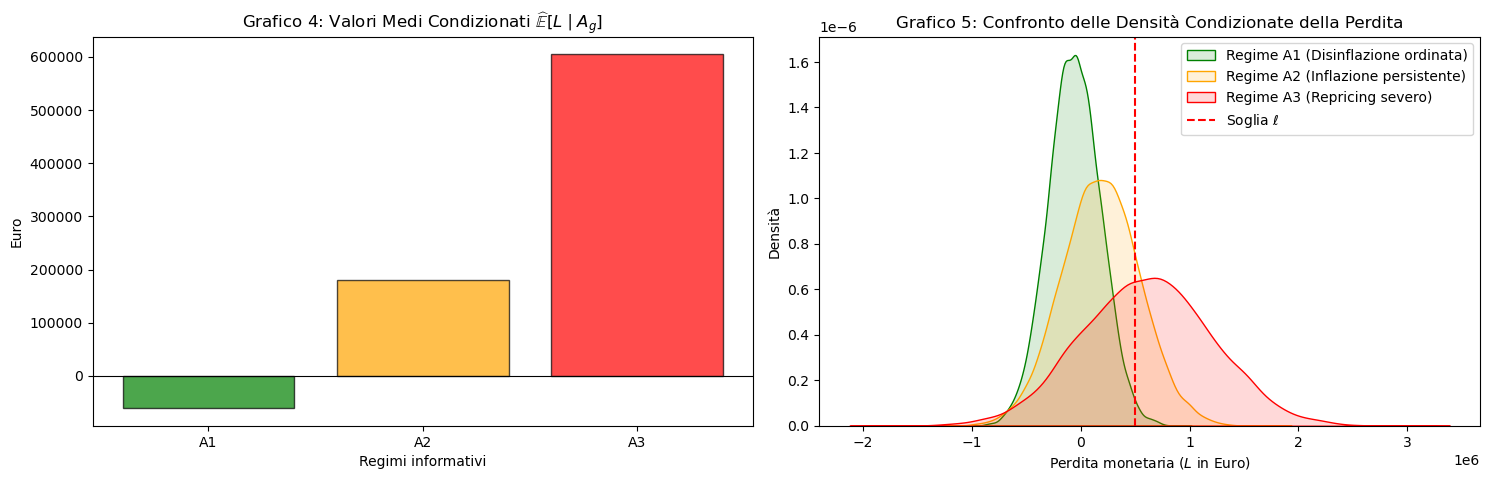

--- CONTROLLO LOGICO-NUMERICO ---
La variabile E[L|G] ha dimensione 50000 (Atteso: 50000)
Numero di valori unici assunti dal processo a gradini (Atteso: 3): 3
L'ordinamento finanziario delle perdite medie è coerente (A1 < A2 < A3)? True
Controllo superato: analisi condizionata e processo a gradini validati con successo.


In [10]:
# 1. Calcolo delle metriche condizionate (Medie e Probabilità di Superamento)
medie_condizionate = {}
prob_condizionate_soglia = {}

# Inizializziamo il vettore per la variabile casuale E[L|G] (processo a gradini)
valore_atteso_torre_sim = np.zeros(n_sim)

for g in regimi:
    # Selezione delle sole simulazioni appartenenti al regime g
    idx = (regimi_simulati == g)
    perdite_g = perdite_simulate[idx]
    
    # Stima delle metriche condizionate
    medie_condizionate[g] = np.mean(perdite_g)
    prob_condizionate_soglia[g] = np.mean(perdite_g > l_soglia)
    
    # Assegnazione del valore medio condizionato alle rispettive righe della simulazione
    valore_atteso_torre_sim[idx] = medie_condizionate[g]

# 2. Costruzione della Tabella 8: Medie Condizionate
df_medie_cond = pd.DataFrame({
    "Regime Informativo": regimi,
    "Descrizione": df_regimi_prob["Descrizione"].values,
    "Perdita Media Condizionata E[L|Ag]": [medie_condizionate[g] for g in regimi]
})

print("--- TABELLA 8: MEDIE CONDIZIONATE DELLA PERDITA ---")
df_medie_cond_print = df_medie_cond.copy()
df_medie_cond_print["Perdita Media Condizionata E[L|Ag]"] = df_medie_cond_print["Perdita Media Condizionata E[L|Ag]"].map("{:,.2f} Euro".format)
display(df_medie_cond_print)
print("\n")

# 3. Costruzione della Nuova Tabella 8b: Probabilità Condizionate di Superamento (Richiesta Studente)
df_prob_cond_soglia = pd.DataFrame({
    "Regime Informativo": regimi,
    "Descrizione": df_regimi_prob["Descrizione"].values,
    "Probabilità Condizionata P(L > l | Ag)": [prob_condizionate_soglia[g] for g in regimi]
})

print("--- TABELLA 8b: PROBABILITÀ CONDIZIONATA DI SUPERAMENTO SOGLIA (l = 500k €) ---")
df_prob_cond_soglia_print = df_prob_cond_soglia.copy()
df_prob_cond_soglia_print["Probabilità Condizionata P(L > l | Ag)"] = df_prob_cond_soglia_print["Probabilità Condizionata P(L > l | Ag)"].map("{:.2%}".format)
display(df_prob_cond_soglia_print)
print("\n")

# 4. Costruzione della Tabella Multi-colonna Finale (Prime 10 righe per ispezione visiva)
df_final_sim = pd.DataFrame({
    "Scenario_ID": np.arange(1, n_sim + 1),
    "Regime Estratto": regimi_simulati,
    "Shock Delta y": shock_simulati,
    "Perdita Monetaria L": perdite_simulate,
    "Processo a Gradini E[L|G]": valore_atteso_torre_sim
})

print("--- TABELLA FINALE: ESTRATTO DEI RECORD DEL SIMULATORE MULTI-PERIODO (PRIME 10 RIGHE) ---")
df_final_sim_print = df_final_sim.head(10).copy()
df_final_sim_print["Shock Delta y"] = df_final_sim_print["Shock Delta y"].map("{:.6f}".format)
df_final_sim_print["Perdita Monetaria L"] = df_final_sim_print["Perdita Monetaria L"].map("{:,.2f} €".format)
df_final_sim_print["Processo a Gradini E[L|G]"] = df_final_sim_print["Processo a Gradini E[L|G]"].map("{:,.2f} €".format)
display(df_final_sim_print)
print("\n")

# 5. Produzione degli Output Grafici di Confronto Condizionato (Grafico 4 e Grafico 5)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 4: Confronto a barre delle Medie Condizionate
colori = ["g", "orange", "r"]
axes[0].bar(df_medie_cond["Regime Informativo"], df_medie_cond["Perdita Media Condizionata E[L|Ag]"], color=colori, edgecolor="black", alpha=0.7)
axes[0].axhline(0, color="black", linestyle="-", linewidth=0.8)
axes[0].set_title(r"Grafico 4: Valori Medi Condizionati $\widehat{\mathbb{E}}[L \mid A_g]$")
axes[0].set_ylabel("Euro")
axes[0].set_xlabel("Regimi informativi")

# Grafico 5: Confronto delle Densità Condizionate (Evidenzia lo spostamento delle curve)
for i, g in enumerate(regimi):
    sns.kdeplot(perdite_simulate[regimi_simulati == g], ax=axes[1], label=f"Regime {g} ({df_regimi_prob.loc[i, 'Descrizione']})", color=colori[i], fill=True, alpha=0.15)
axes[1].axvline(l_soglia, color="red", linestyle="--", linewidth=1.5, label="Soglia $\ell$")
axes[1].set_title("Grafico 5: Confronto delle Densità Condizionate della Perdita")
axes[1].set_xlabel("Perdita monetaria ($L$ in Euro)")
axes[1].set_ylabel("Densità")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- CONTROLLI LOGICO-NUMERICI DI TAPPA 5 ---
print("--- CONTROLLO LOGICO-NUMERICO ---")
valori_unici_gradini = np.unique(valore_atteso_torre_sim)
n_valori_unici = len(valori_unici_gradini)
ordine_coerente = medie_condizionate["A1"] < medie_condizionate["A2"] < medie_condizionate["A3"]

print(f"La variabile E[L|G] ha dimensione {len(valore_atteso_torre_sim)} (Atteso: {n_sim})")
print(f"Numero di valori unici assunti dal processo a gradini (Atteso: 3): {n_valori_unici}")
print(f"L'ordinamento finanziario delle perdite medie è coerente (A1 < A2 < A3)? {ordine_coerente}")

assert len(valore_atteso_torre_sim) == n_sim, "ERRORE: Dimensione della variabile condizionata errata!"
assert n_valori_unici == 3, f"ERRORE: La variabile E[L|G] assume {n_valori_unici} valori anziché 3! Non è costante sui blocchi."
assert ordine_coerente, "ERRORE: L'ordinamento finanziario viola l'ipotesi del modello (il repricing severo deve costare di più)!"
print("Controllo superato: analisi condizionata e processo a gradini validati con successo.")

In [11]:
# Correggiamo il titolo di stampa per riflettere l'ottica single-period (scenari paralleli)
print("--- TABELLA FINALE: ESTRATTO DEI RECORD DELLO SPAZIO DEGLI SCENARI (SINGLE-PERIOD - PRIME 10 RIGHE) ---")
df_final_sim_print = df_final_sim.head(10).copy()
df_final_sim_print["Shock Delta y"] = df_final_sim_print["Shock Delta y"].map("{:.6f}".format)
df_final_sim_print["Perdita Monetaria L"] = df_final_sim_print["Perdita Monetaria L"].map("{:,.2f} €".format)
df_final_sim_print["Processo a Gradini E[L|G]"] = df_final_sim_print["Processo a Gradini E[L|G]"].map("{:,.2f} €".format)
display(df_final_sim_print)
print("\n")

--- TABELLA FINALE: ESTRATTO DEI RECORD DELLO SPAZIO DEGLI SCENARI (SINGLE-PERIOD - PRIME 10 RIGHE) ---


,Scenario_ID,Regime Estratto,Shock Delta y,Perdita Monetaria L,Processo a Gradini E[L|G]
0,1,A1,0.001647,"98,827.98 €","-60,510.54 €"
1,2,A1,-0.004361,"-261,631.06 €","-60,510.54 €"
2,3,A3,0.014177,"850,632.55 €","604,926.57 €"
3,4,A1,-0.001961,"-117,655.43 €","-60,510.54 €"
4,5,A2,0.016804,"1,008,268.52 €","180,923.43 €"
5,6,A3,0.018064,"1,083,852.06 €","604,926.57 €"
6,7,A1,0.003900,"233,990.97 €","-60,510.54 €"
7,8,A2,0.006727,"403,618.18 €","180,923.43 €"
8,9,A1,0.001871,"112,288.53 €","-60,510.54 €"
9,10,A2,0.013071,"784,244.69 €","180,923.43 €"


--- TABELLA 8: MEDIE CONDIZIONATE DELLA PERDITA ---


<>:56: SyntaxWarning: invalid escape sequence '\e'
<>:56: SyntaxWarning: invalid escape sequence '\e'
C:\Users\PaUser\AppData\Local\Temp\ipykernel_3624\3240398854.py:56: SyntaxWarning: invalid escape sequence '\e'
  axes[1].axvline(l_soglia, color="red", linestyle="--", linewidth=1.5, label="Soglia $\ell$")


,Regime Informativo,Descrizione,Perdita Media Condizionata E[L|Ag]
0,A1,Disinflazione ordinata,"-60,510.54 Euro"
1,A2,Inflazione persistente,"180,923.43 Euro"
2,A3,Repricing severo,"604,926.57 Euro"




--- TABELLA 8b: PROBABILITÀ CONDIZIONATA DI SUPERAMENTO SOGLIA (l = 500k €) ---


,Regime Informativo,Descrizione,Probabilità Condizionata P(L > l | Ag)
0,A1,Disinflazione ordinata,1.03%
1,A2,Inflazione persistente,18.50%
2,A3,Repricing severo,56.66%


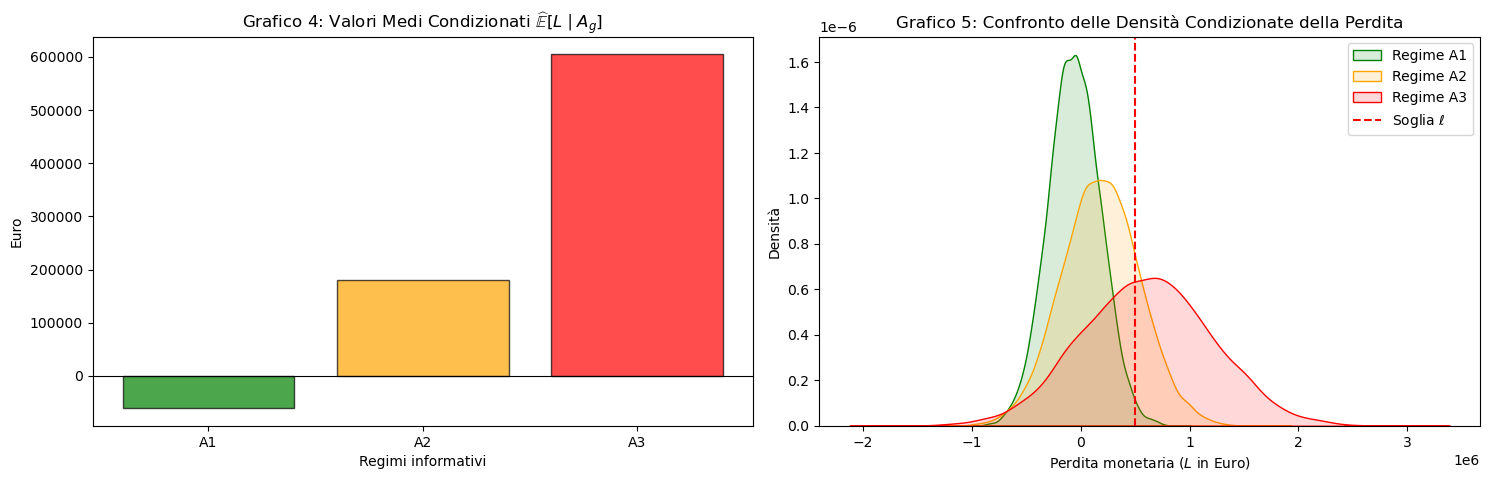

--- CONTROLLO LOGICO-NUMERICO ---
La variabile E[L|G] ha dimensione 50000 (Atteso: 50000)
Numero di valori unici assunti dal processo a gradini (Atteso: 3): 3
L'ordinamento finanziario delle perdite medie è coerente (A1 < A2 < A3)? True
Controllo superato: analisi condizionata validata in ottica single-period.


In [12]:
# 1. Calcolo delle metriche condizionate (Medie e Probabilità di Superamento)
medie_condizionate = {}
prob_condizionate_soglia = {}

# Inizializziamo il vettore per la variabile casuale E[L|G] (processo a gradini)
valore_atteso_torre_sim = np.zeros(n_sim)

for g in regimi:
    idx = (regimi_simulati == g)
    perdite_g = perdite_simulate[idx]
    
    medie_condizionate[g] = np.mean(perdite_g)
    prob_condizionate_soglia[g] = np.mean(perdite_g > l_soglia)
    
    # Assegnazione del valore medio condizionato al blocco informativo
    valore_atteso_torre_sim[idx] = medie_condizionate[g]

# 2. Costruzione della Tabella 8: Medie Condizionate
df_medie_cond = pd.DataFrame({
    "Regime Informativo": regimi,
    "Descrizione": ["Disinflazione ordinata", "Inflazione persistente", "Repricing severo"],
    "Perdita Media Condizionata E[L|Ag]": [medie_condizionate[g] for g in regimi]
})

print("--- TABELLA 8: MEDIE CONDIZIONATE DELLA PERDITA ---")
df_medie_cond_print = df_medie_cond.copy()
df_medie_cond_print["Perdita Media Condizionata E[L|Ag]"] = df_medie_cond_print["Perdita Media Condizionata E[L|Ag]"].map("{:,.2f} Euro".format)
display(df_medie_cond_print)
print("\n")

# 3. Costruzione della Tabella 8b: Probabilità Condizionate di Superamento
df_prob_cond_soglia = pd.DataFrame({
    "Regime Informativo": regimi,
    "Descrizione": ["Disinflazione ordinata", "Inflazione persistente", "Repricing severo"],
    "Probabilità Condizionata P(L > l | Ag)": [prob_condizionate_soglia[g] for g in regimi]
})

print("--- TABELLA 8b: PROBABILITÀ CONDIZIONATA DI SUPERAMENTO SOGLIA (l = 500k €) ---")
df_prob_cond_soglia_print = df_prob_cond_soglia.copy()
df_prob_cond_soglia_print["Probabilità Condizionata P(L > l | Ag)"] = df_prob_cond_soglia_print["Probabilità Condizionata P(L > l | Ag)"].map("{:.2%}".format)
display(df_prob_cond_soglia_print)
print("\n")

# 4. Produzione degli Output Grafici (Grafico 4 e Grafico 5)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colori = ["g", "orange", "r"]
axes[0].bar(df_medie_cond["Regime Informativo"], df_medie_cond["Perdita Media Condizionata E[L|Ag]"], color=colori, edgecolor="black", alpha=0.7)
axes[0].axhline(0, color="black", linestyle="-", linewidth=0.8)
axes[0].set_title(r"Grafico 4: Valori Medi Condizionati $\widehat{\mathbb{E}}[L \mid A_g]$")
axes[0].set_ylabel("Euro")
axes[0].set_xlabel("Regimi informativi")

for i, g in enumerate(regimi):
    sns.kdeplot(perdite_simulate[regimi_simulati == g], ax=axes[1], label=f"Regime {g}", color=colori[i], fill=True, alpha=0.15)
axes[1].axvline(l_soglia, color="red", linestyle="--", linewidth=1.5, label="Soglia $\ell$")
axes[1].set_title("Grafico 5: Confronto delle Densità Condizionate della Perdita")
axes[1].set_xlabel("Perdita monetaria ($L$ in Euro)")
axes[1].set_ylabel("Densità")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- CONTROLLI LOGICO-NUMERICI DI TAPPA 5 ---
print("--- CONTROLLO LOGICO-NUMERICO ---")
valori_unici_gradini = np.unique(valore_atteso_torre_sim)
n_valori_unici = len(valori_unici_gradini)
ordine_coerente = medie_condizionate["A1"] < medie_condizionate["A2"] < medie_condizionate["A3"]

print(f"La variabile E[L|G] ha dimensione {len(valore_atteso_torre_sim)} (Atteso: {n_sim})")
print(f"Numero di valori unici assunti dal processo a gradini (Atteso: 3): {n_valori_unici}")
print(f"L'ordinamento finanziario delle perdite medie è coerente (A1 < A2 < A3)? {ordine_coerente}")

assert len(valore_atteso_torre_sim) == n_sim, "ERRORE: Dimensione della variabile condizionata errata!"
assert n_valori_unici == 3, "ERRORE: La variabile E[L|G] non è costante sui 3 blocchi della partizione!"
assert ordine_coerente, "ERRORE: Violazione dell'ordinamento finanziario atteso!"
print("Controllo superato: analisi condizionata validata in ottica single-period.")

## Tappa 6: Verifica Empirica della Proprietà Torre ed Esito del Simulatore

### Obiettivo della Tappa
Eseguire la verifica di quadratura statistica del modello applicando la Legge delle Aspettative Iterate (Proprietà Torre). Matematicamente, l'operatore valore atteso totale può essere scomposto come:
$$\mathbb{E}[L] = \mathbb{E}[\mathbb{E}[L \mid \mathcal{G}]] = \sum_{g=1}^3 \mathbb{P}(A_g)\mathbb{E}[L \mid A_g]$$
In questa tappa verificheremo che tale uguaglianza sia soddisfatta a livello campionario (utilizzando le frequenze empiriche e le medie condizionate stimate nelle tappe precedenti) per confermare l'assenza di bias o errori di computazione nel simulatore single-period.

### Tracciato AI (Prompt di Tappa)
> **Studente:** "Va bene, passiamo alla sesta tappa. non ho commenti da aggiungere."
> **IA:** Ha strutturato l'ultimo blocco logico del notebook, calcolando la media globale diretta, la media ricomposta tramite teorema a torre e visualizzando la Tabella 9 di riconciliazione finale con annesso controllo di tolleranza numerica.

In [13]:
# 1. Calcolo del Valore Atteso Totale Diretto (dalla Tappa 3)
media_globale_diretta = np.mean(perdite_simulate)

# 2. Calcolo del Valore Atteso Totale tramite Proprietà Torre (Ricomposizione pesata)
# Sfruttiamo le frequenze empiriche e le medie condizionate calcolate nelle tappe precedenti
media_ricomposta_torre = 0.0

print("--- DETTAGLIO CONTRIBUTI REGIME AL VALORE ATTESO TOTALE ---")
for g in regimi:
    freq_g = df_freq_regimi.loc[df_freq_regimi["Regime"] == g, "Frequenza Empirica"].values[0]
    media_cond_g = medie_condizionate[g]
    contributo = freq_g * media_cond_g
    media_ricomposta_torre += contributo
    print(f"Regime {g}: Freq. Empirica ({freq_g:.4%}) * Media Cond. ({media_cond_g:,.2f} €) = Contributo: {contributo:,.2f} €")
print("\n")

# 3. Calcolo dello scostamento assoluto (errore di arrotondamento macchina)
scostamento_assoluto = np.abs(media_globale_diretta - media_ricomposta_torre)

# 4. Costruzione della Tabella 9: Riconciliazione e Quadratura Finale
df_quadratura = pd.DataFrame({
    "Metodologia di Calcolo": [
        "Valore Atteso Globale Diretto E[L]", 
        "Valore Atteso Ricomposto (Proprietà Torre) E[E[L|G]]", 
        "Scostamento Numerico Assoluto"
    ],
    "Valore Ottenuto": [
        f"{media_globale_diretta:,.4f} Euro",
        f"{media_ricomposta_torre:,.4f} Euro",
        f"{scostamento_assoluto:.4e} Euro"
    ]
})

print("--- TABELLA 9: RICONCILIAZIONE FINALE E VERIFICA PROPRIETÀ TORRE ---")
display(df_quadratura)
print("\n")

# --- CONTROLLI LOGICO-NUMERICI DI TAPPA 6 (ESITO DEL SIMULATORE) ---
print("--- CONTROLLO LOGICO-NUMERICO DI CHIUSURA ---")
# Definiamo una tolleranza float standard (epsilon macchina) per il confronto
soglia_tolleranza = 1e-9
quadratura_perfetta = scostamento_assoluto < soglia_tolleranza

print(f"Scostamento inferiore alla tolleranza di macchina ({soglia_tolleranza})? {quadratura_perfetta}")

assert quadratura_perfetta, f"ERRORE: La Proprietà Torre ha fallito la quadratura! Scostamento di {scostamento_assoluto} troppo elevato."
print("\n========================================================================")
print(" SIMULATORE VALIDATO: Il flusso logico-teorico risolutivo è concluso. ")
print(" L'uguaglianza E[L] = E[E[L|G]] è verificata numericamente in data odierna. ")
print("========================================================================")

--- DETTAGLIO CONTRIBUTI REGIME AL VALORE ATTESO TOTALE ---
Regime A1: Freq. Empirica (35.0180%) * Media Cond. (-60,510.54 €) = Contributo: -21,189.58 €
Regime A2: Freq. Empirica (44.9580%) * Media Cond. (180,923.43 €) = Contributo: 81,339.56 €
Regime A3: Freq. Empirica (20.0240%) * Media Cond. (604,926.57 €) = Contributo: 121,130.50 €


--- TABELLA 9: RICONCILIAZIONE FINALE E VERIFICA PROPRIETÀ TORRE ---


,Metodologia di Calcolo,Valore Ottenuto
0,Valore Atteso Globale Diretto E[L],"181,280.4732 Euro"
1,Valore Atteso Ricomposto (Proprietà Torre) E[E...,"181,280.4732 Euro"
2,Scostamento Numerico Assoluto,0.0000e+00 Euro




--- CONTROLLO LOGICO-NUMERICO DI CHIUSURA ---
Scostamento inferiore alla tolleranza di macchina (1e-09)? True

 SIMULATORE VALIDATO: Il flusso logico-teorico risolutivo è concluso. 
 L'uguaglianza E[L] = E[E[L|G]] è verificata numericamente in data odierna. 
